# Randomly sample a local receptive field at a split / merge error

Uses a **relabeled** `dataset_cache_<brain>_mcl100_add.pkl` to pick a random
location of a **split error** and a **merge error**, then reads the image
patch (the *local receptive field*) centered on each.

## Where the split/merge info lives in the cache (the question)

A plain `_mcl100.pkl` carries only the two skeleton graphs. The `_add.pkl`
variant is produced by `scripts/relabel_cache.py`, which reads the predicted
segmentation at every GT node and **bakes the ground-truth error labels into
the cache** (see `data_modules/canonical_labeling.py`). So the error info is
*already there* — no segmentation read needed:

| field (on `gt_graph` / payload)        | meaning |
|----------------------------------------|---------|
| `gt_graph.edge_error` (`gt_edge_error`)| one code **per GT edge**, parallel to `list(gt_graph.edges)`. Codes: `CORRECT=0`, `SPLIT=1`, `OMIT=2`, `MERGED=3` |
| `gt_graph.node_label` (`gt_node_canonical_label`) | predicted segment id at each GT node (`0` = background) |
| `gt_graph.merge_sites` (`gt_merge_sites`) | list of `{segment_id, gt_neuron, xyz}` — geometric merge locations (µm) |
| `gt_graph.merge_labels` (`gt_merge_labels`) | segment ids flagged as merges |

**Split error** = a GT edge whose two endpoints fall on *different* predicted
segments (the segmentation broke one neuron into pieces) → `edge_error == SPLIT`.
We take that edge's location directly from `node_xyz`.

**Merge error** = one predicted segment spanning *two* GT neurons. The clean,
ready-to-use locations are `gt_merge_sites[*]['xyz']` (we also show how to
recover them from `edge_error == MERGED` edges).

> Note: `proofreader_evolve/harness/dataset.py::candidate_split_sites` /
> `candidate_merge_sites` are a *different* thing — GT-free geometric **candidate
> proposals** (what *might* be an error), not the confirmed GT errors used here.

The image-patch read below mirrors `notebooks/load_skeletons_from_cache.ipynb`.
Kernel: **panda**.

## 0. Setup

In [1]:
import os
import sys
import pickle
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

# Same env / path setup as notebooks/load_skeletons_from_cache.ipynb.
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../configs/zihan_gcs_token.json"
os.environ["AWS_EC2_METADATA_DISABLED"] = "true"

from agentic_neuron_proofreader.utils import img_util
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset
from agentic_neuron_proofreader.data_modules import canonical_labeling as cl

# --- Parameters -----------------------------------------------------------
BRAIN_ID = "709221"          # any brain with a *_add.pkl in ../cache
MINLEN = 100
PATCH = 128                   # local receptive field = PATCH^3 voxels, centered on the error
SEED = None                   # None -> a different random error each run; set an int to reproduce
READ_IMAGE = True             # set False to skip the GCS image read (locations only)
SHOW_SLICES = True            # also show the CENTER SLICE (mid-plane) next to each MIP

PATCH_SHAPE = (PATCH, PATCH, PATCH)
rng = np.random.default_rng(SEED)

cache_path = f"../cache/dataset_cache_{BRAIN_ID}_mcl{MINLEN}_add.pkl"
print("cache:", cache_path, "\nexists:", os.path.exists(cache_path))

cache: ../cache/dataset_cache_709221_mcl100_add.pkl 
exists: True


## 1. Load the `_add.pkl` cache and confirm the error labels are present

If `edge_error` / `merge_sites` are missing, this cache was never relabeled —
run `scripts/relabel_cache.py --brain <id>` to build a real `_add.pkl`.

In [2]:
ds = BrainDataset.load_from_cache(cache_path)
gt = ds.gt_graph
frags = ds.fragments_graph

edge_error = getattr(gt, "edge_error", None)
node_label = getattr(gt, "node_label", None)
merge_sites = getattr(gt, "merge_sites", None)

assert edge_error is not None, (
    "edge_error missing -> this cache was not relabeled (run relabel_cache.py)."
)
edge_error = np.asarray(edge_error)

# Segmentation reader (the UNet *volume* visualized in load_skeletons). The
# relabeled cache stores its path; fall back to building it from the brain id.
seg_path = getattr(ds, "segmentation_path", None)
if seg_path:
    segmentation = img_util.TensorStoreImage(seg_path)
else:
    print("note: no segmentation_path on cache -> segmentation MIP will be skipped")
    segmentation = None

print(gt.summary(prefix="GroundTruth"))
print(frags.summary(prefix="Fragments"))
print("\nedge_error code counts:")
counts = Counter(int(c) for c in edge_error)
for code, name in cl.EDGE_ERROR_NAMES.items():
    print(f"  {name:<8} ({code}): {counts.get(code, 0):,}")
print("\nmerge_sites:", 0 if merge_sites is None else len(merge_sites))
print("anisotropy (um/voxel):", gt.anisotropy)
print("segmentation_path:", seg_path)

I0620 15:51:19.812546  654016 google_auth_provider.cc:149] Using credentials at ../configs/zihan_gcs_token.json
I0620 15:51:19.814703  654016 google_auth_provider.cc:165] Using ServiceAccount AuthProvider


GroundTruth Graph
# Connected Components: 34
# Nodes: 1,040,917
# Edges: 1,040,883
Memory Consumption: 49.31 GBs
Fragments Graph
# Connected Components: 0
# Nodes: 0
# Edges: 0
Memory Consumption: 49.31 GBs

edge_error code counts:
  correct  (0): 328,366
  split    (1): 15,707
  omit     (2): 37,880
  merged   (3): 658,930

merge_sites: 0
anisotropy (um/voxel): [0.748 0.748 1.   ]
segmentation_path: gs://allen-nd-goog/from_google/709221/whole_brain/20251001_mean40.stddev105.mask.136168199.no_omitted_20k.ffn.mt_0.1/


## 2. Helper: visualize the local receptive field at an error location

Mirrors `load_skeletons_from_cache.ipynb`: from a physical-µm center it reads the
patch and shows four **MIPs** (Maximum Intensity Projections — `np.max` along each
axis, the XY / XZ / YZ views `load_skeletons` uses):

1. **Raw image** (`ds.img`) — the microscopy volume.
2. **UNet segmentation** (`segmentation`) — each segment id a distinct color; a GT
   neuron crossing a color boundary is a *split*, one color spanning two neurons is
   a *merge*.
3. **GT skeleton** (`gt_graph`, lime) — the human-traced answer key.
4. **UNet fragments** (`fragments_graph`, cyan) — skeletons extracted from the
   segmentation, colored per connected component.

`node_xyz` is in microns `(x, y, z)`; `img_util.to_voxels` converts to the image's
`(z, y, x)` voxel center, and the patch *origin* (for `nodes_in_patch`) is that
center minus half the patch.

### MIP vs. depth slices — what the two views show

Both collapse the 3D patch to 2D panels (XY / XZ / YZ columns), but differently, so
they answer different questions. The slice view shows **several depths in one
figure** — one row per depth fraction (`SLICE_FRACTIONS`, e.g. 20/40/50/60/80%) —
so you can watch the structure enter and leave the plane:

| | **MIP** (`plot_mips`) | **depth slices** (`plot_slices`) |
|---|---|---|
| operation | `np.max(patch, axis=k)` — brightest voxel over the whole depth | `patch[int(f*depth)]` for each fraction `f` — one true plane per row |
| depth | **projects the entire cube** onto one panel | **one plane per panel**; rows step through depth |
| a thin neurite | always visible — its bright voxels win the max, wherever in depth | visible only in the rows whose plane it actually crosses |
| overlap | structures at different depths **pile on top of each other** (can look falsely "touching") | no depth overlay — each panel is what truly sits at that depth |
| reading it | one glance: "is the structure there / where is the error" | walk down a column: "at which depth does it appear, and do two neurites coincide in the *same* plane" |

**Why both.** A neurite is a thin filament threading through the cube; any single
plane cuts it at one depth and shows little, while the MIP guarantees it is visible
but flattens foreground and background together. Stepping through depth slices
resolves the MIP's main ambiguity: two lines that *cross* in a MIP may merely be
**stacked in depth** — if they appear together in the same slice row, they truly
coincide there (the visual test for a real merge contact vs. an apparent one); for a
split, the slices show whether the gap is a true break at that depth or just a piece
sitting at another depth that the MIP folded in.

In [3]:
SLICE_FRACTIONS = (0.2, 0.4, 0.5, 0.6, 0.8)  # depth fractions for plot_slices rows


def receptive_field(xyz_um, shape=PATCH_SHAPE, read_image=READ_IMAGE):
    """Center voxel + (optionally) the raw image patch for a physical-µm location."""
    center_voxel = img_util.to_voxels(xyz_um, gt.anisotropy)  # (z, y, x)
    patch = ds.img.read(center_voxel, shape) if read_image else None
    if patch is not None:
        patch = np.squeeze(patch)  # reader may add leading singleton axes
    return center_voxel, patch


def plot_slices(patch, title="", fractions=SLICE_FRACTIONS):
    """Several single-plane SLICES at increasing depth, in ONE figure.

    Unlike a MIP (which maxes over the whole depth), each panel is one true imaging
    layer `patch[int(f*depth)]` — no depth overlay. Rows = depth fraction along the
    projection axis (e.g. 0.2..0.8 of z for the XY column); columns = XY / XZ / YZ.
    Walking down a column shows how the structure enters and leaves the plane with
    depth — what a single mid-slice cannot convey and a MIP flattens away.
    """
    nz, ny, nx = patch.shape
    names = ["XY (vary z)", "XZ (vary y)", "YZ (vary x)"]
    sizes = [nz, ny, nx]              # depth axis for each column
    vmax = np.percentile(patch, 99.9)

    nrows = len(fractions)
    fig, axs = plt.subplots(nrows, 3, figsize=(10, 3.2 * nrows))
    axs = np.atleast_2d(axs)
    for r, frac in enumerate(fractions):
        idx = [min(int(frac * s), s - 1) for s in sizes]  # plane index per column
        planes = [patch[idx[0]], patch[:, idx[1]], patch[:, :, idx[2]]]
        for c, (ax, plane, nm) in enumerate(zip(axs[r], planes, names)):
            ax.imshow(plane, cmap="gray", vmax=vmax)
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(nm, fontsize=14)
            if c == 0:
                ax.set_ylabel(f"{int(frac * 100)}% depth\n(plane {idx[0]})",
                              fontsize=12)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_receptive_field(xyz_um, title, shape=PATCH_SHAPE):
    """Image + segmentation + GT + fragment views at an error location.

    Same panels as load_skeletons_from_cache.ipynb (MIPs), centered on the error.
    When SHOW_SLICES is True, the RAW IMAGE also gets a multi-depth SLICE figure
    (rows = SLICE_FRACTIONS) right after its MIP, for comparison.
    """
    if not READ_IMAGE:
        center = img_util.to_voxels(xyz_um, gt.anisotropy)
        print(f"[{title}] center voxel (z,y,x)={center}; READ_IMAGE=False -> no plot")
        return center

    center_voxel, img_patch = receptive_field(xyz_um, shape)
    # Patch origin in global voxel space (center - half), for *_in_patch lookups.
    offset = tuple(c - s // 2 for c, s in zip(center_voxel, shape))

    print(f"=== {title} ===")
    print(f"  location (um): {tuple(round(v, 1) for v in xyz_um)}")
    print(f"  center voxel (z,y,x): {center_voxel}   patch: {img_patch.shape}")

    # 1) Raw image — MIP, then (optional) multi-depth slices.
    print("Raw image (MIP):")
    img_util.plot_mips(img_patch)
    if SHOW_SLICES:
        print(f"Raw image (slices at {[int(f*100) for f in SLICE_FRACTIONS]}% depth):")
        plot_slices(img_patch)

    # 2) UNet segmentation — MIP, then (optional) center slice. Remap raw ids to
    #    0..N first so the colormap stays small (raw ids can be huge).
    if segmentation is not None:
        seg_patch = np.squeeze(segmentation.read(center_voxel, shape))
        _, seg_remapped = np.unique(seg_patch, return_inverse=True)
        seg_remapped = seg_remapped.reshape(seg_patch.shape).astype(np.int32)
        n_seg = int(len(np.unique(seg_patch[seg_patch > 0])))
        print(f"UNet segmentation ({n_seg} segment ids in patch) (MIP):")
        img_util.plot_segmentation_mips(seg_remapped)

    # 3+4) GT and fragment skeleton MIPs, colored per connected component.
    #      (Skeletons are sparse points/lines -> a single slice is near-empty, so
    #      these stay MIP-only.)
    gt_nodes, gt_ncomp = gt.nodes_in_patch(offset, shape, return_components=True)
    gt_edges, gt_ecomp = gt.edges_in_patch(offset, shape, return_components=True)
    fr_nodes, fr_ncomp = frags.nodes_in_patch(offset, shape, return_components=True)
    fr_edges, fr_ecomp = frags.edges_in_patch(offset, shape, return_components=True)
    print(f"GT nodes/edges in patch: {len(gt_nodes)}/{len(gt_edges)}   "
          f"fragment nodes/edges: {len(fr_nodes)}/{len(fr_edges)}")
    img_util.plot_skeleton_mips(
        {
            "GT": {"nodes": gt_nodes, "node_components": gt_ncomp,
                   "edges": gt_edges, "components": gt_ecomp, "color": "lime"},
            "UNet Fragments": {"nodes": fr_nodes, "node_components": fr_ncomp,
                               "edges": fr_edges, "components": fr_ecomp,
                               "color": "cyan"},
        },
        shape,
        separate_rows=True,
    )
    return center_voxel

## 3. Randomly select a SPLIT error and read its receptive field

A split is a GT edge labeled `EDGE_SPLIT`: its two endpoints landed on different
predicted segments. The location is the edge midpoint.

split edge #542292: nodes (542259, 542260)
  seg ids: 669567784 vs 4003191830  (different -> split)
  gt neuron: N057-709221-SA

=== SPLIT error @ (23798.2, 18764.0, 8867.9) um ===
  location (um): (23798.2, 18764.0, 8867.9)
  center voxel (z,y,x): (8867, 25085, 31815)   patch: (128, 128, 128)
Raw image (MIP):


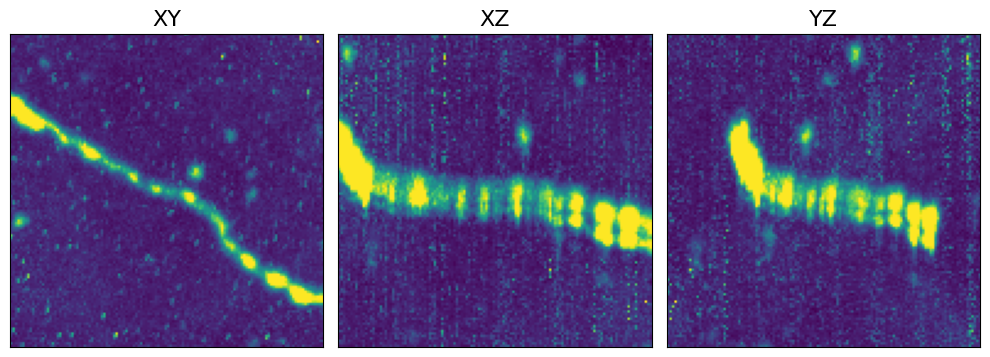

Raw image (slices at [20, 40, 50, 60, 80]% depth):


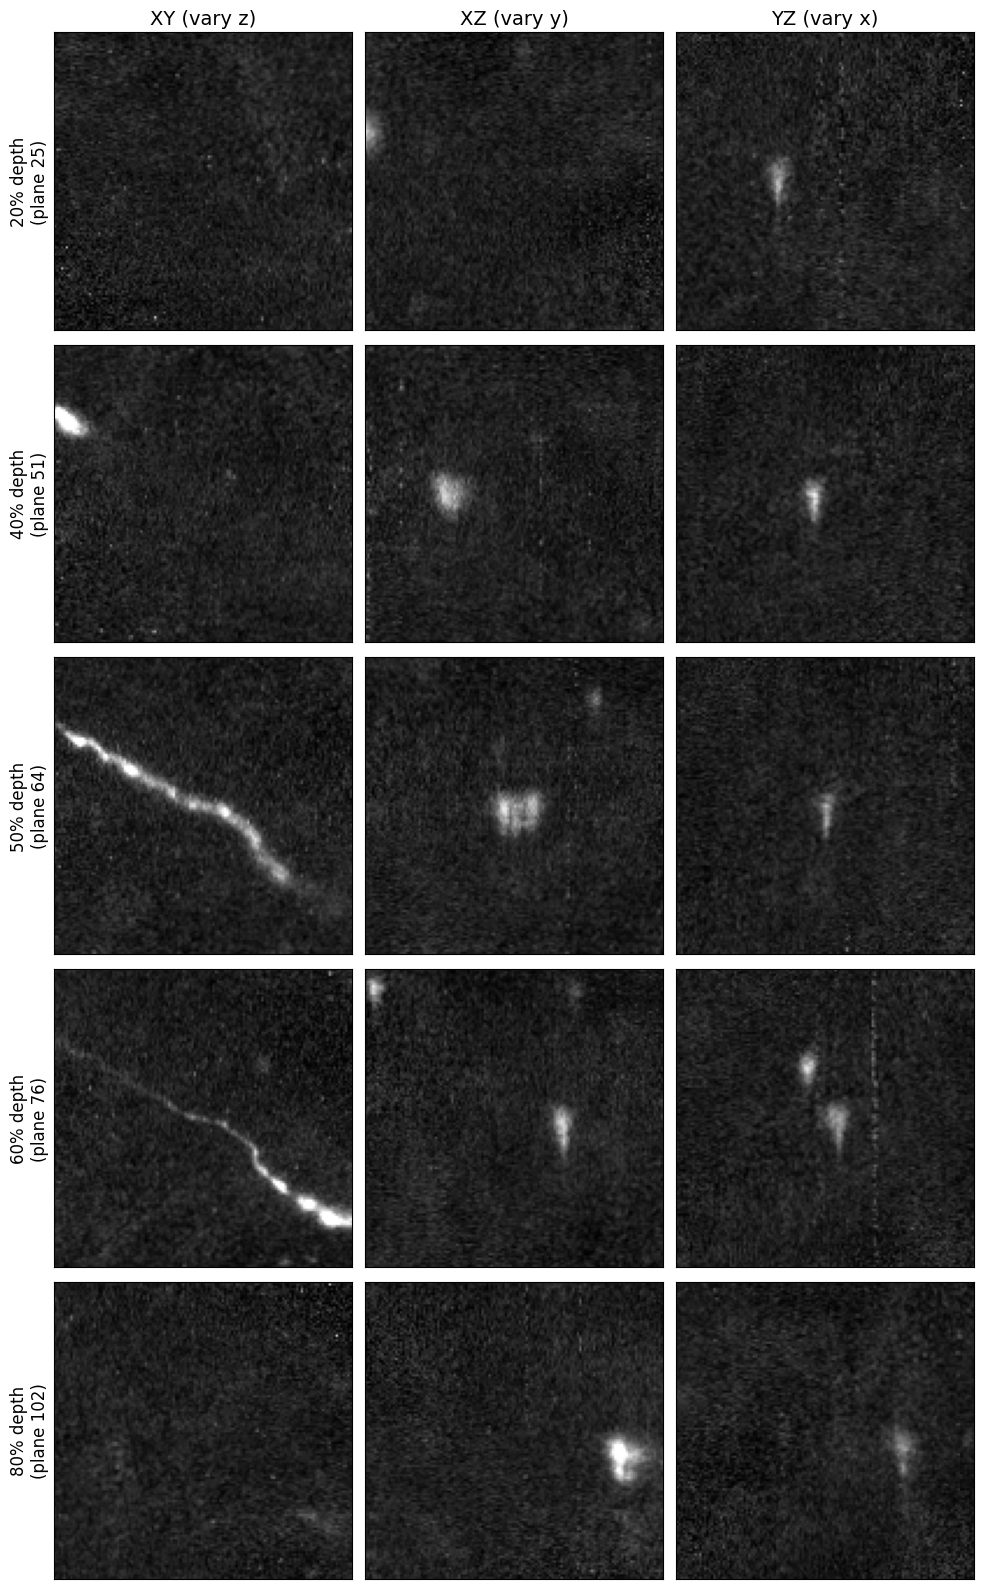

UNet segmentation (5 segment ids in patch) (MIP):


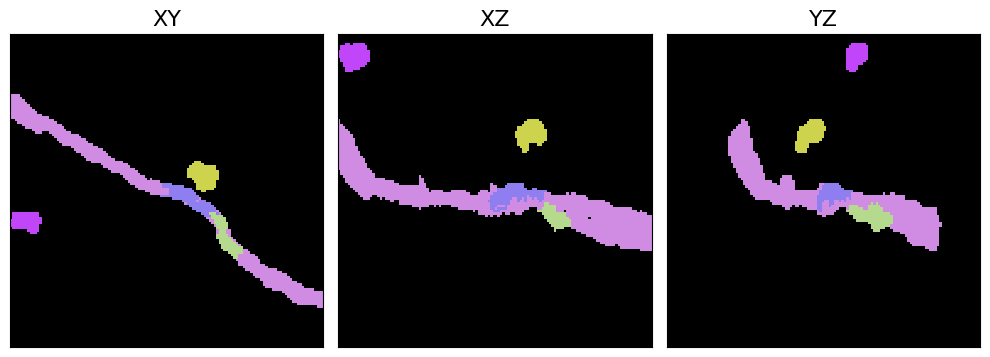

GT nodes/edges in patch: 35/34   fragment nodes/edges: 0/0


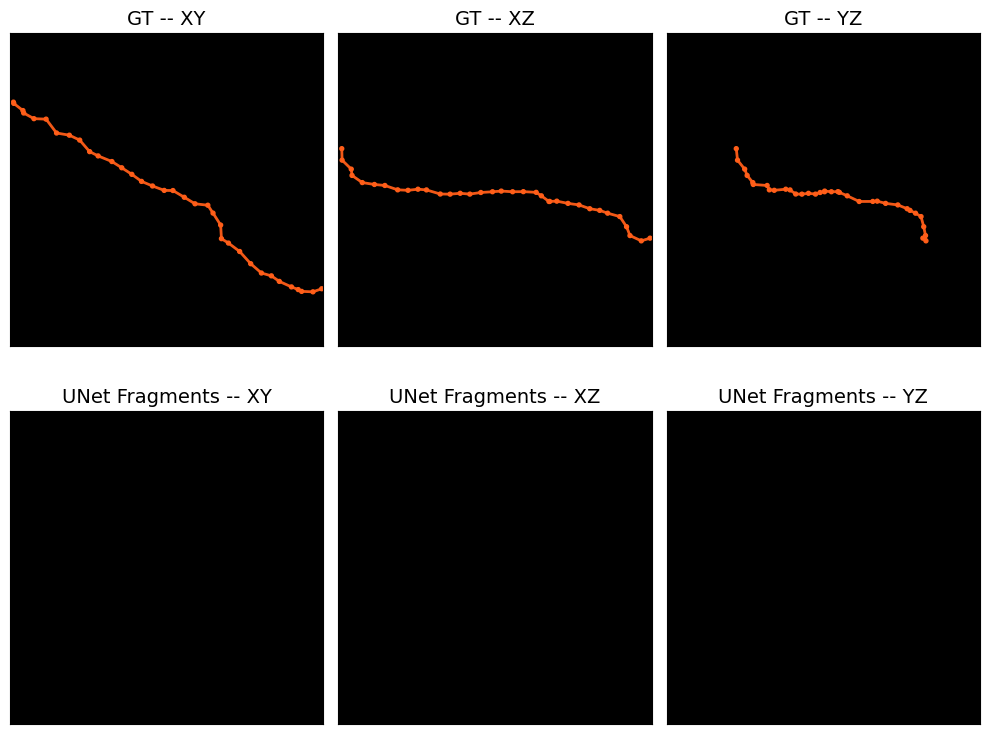

In [4]:
edges = list(gt.edges)  # parallel to edge_error
split_idx = np.flatnonzero(edge_error == cl.EDGE_SPLIT)
assert split_idx.size, "no split edges in this cache"

pick = int(rng.choice(split_idx))
i, j = edges[pick]
xyz_i, xyz_j = gt.node_xyz[i], gt.node_xyz[j]
split_xyz = tuple(map(float, (xyz_i + xyz_j) / 2.0))  # edge midpoint (um)

print(f"split edge #{pick}: nodes ({i}, {j})")
print(f"  seg ids: {gt.node_label[i]} vs {gt.node_label[j]}  (different -> split)")
print(f"  gt neuron: {gt.node_segment_id(i)}\n")

split_center = show_receptive_field(
    split_xyz, f"SPLIT error @ {tuple(round(v, 1) for v in split_xyz)} um"
)

## 4. Randomly select a GEOMETRIC-WALK MERGE error and read its receptive field

We deliberately pick a **geometric-walk-only** merge here — a segment the node-count
rule **misses** (it touches only one GT neuron's nodes, because the fused partner is
unlabelled), recovered solely by the geometric walk. Every entry in `gt_merge_sites`
comes from the geometric walk, but some of those segments are *also* caught by the
node-count rule; we filter those out so this section always shows the geometric-only
kind. The complementary node-count merge is shown in section 4d.

`gt_merge_sites` carries a clean `xyz` (µm) per site. If the cache predates the
geometric walk (no sites), we fall back to a random `EDGE_MERGED` edge midpoint.

merged edge #802988: nodes (802708, 802709), seg id 669567784

=== GEOMETRIC-WALK MERGE @ (24343.7, 21161.2, 8963.0) um ===
  location (um): (24343.7, 21161.2, 8963.0)
  center voxel (z,y,x): (8963, 28290, 32545)   patch: (128, 128, 128)
Raw image (MIP):


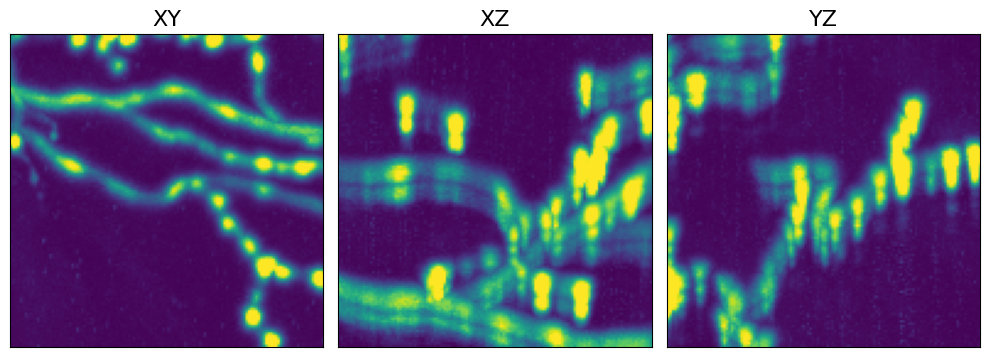

Raw image (slices at [20, 40, 50, 60, 80]% depth):


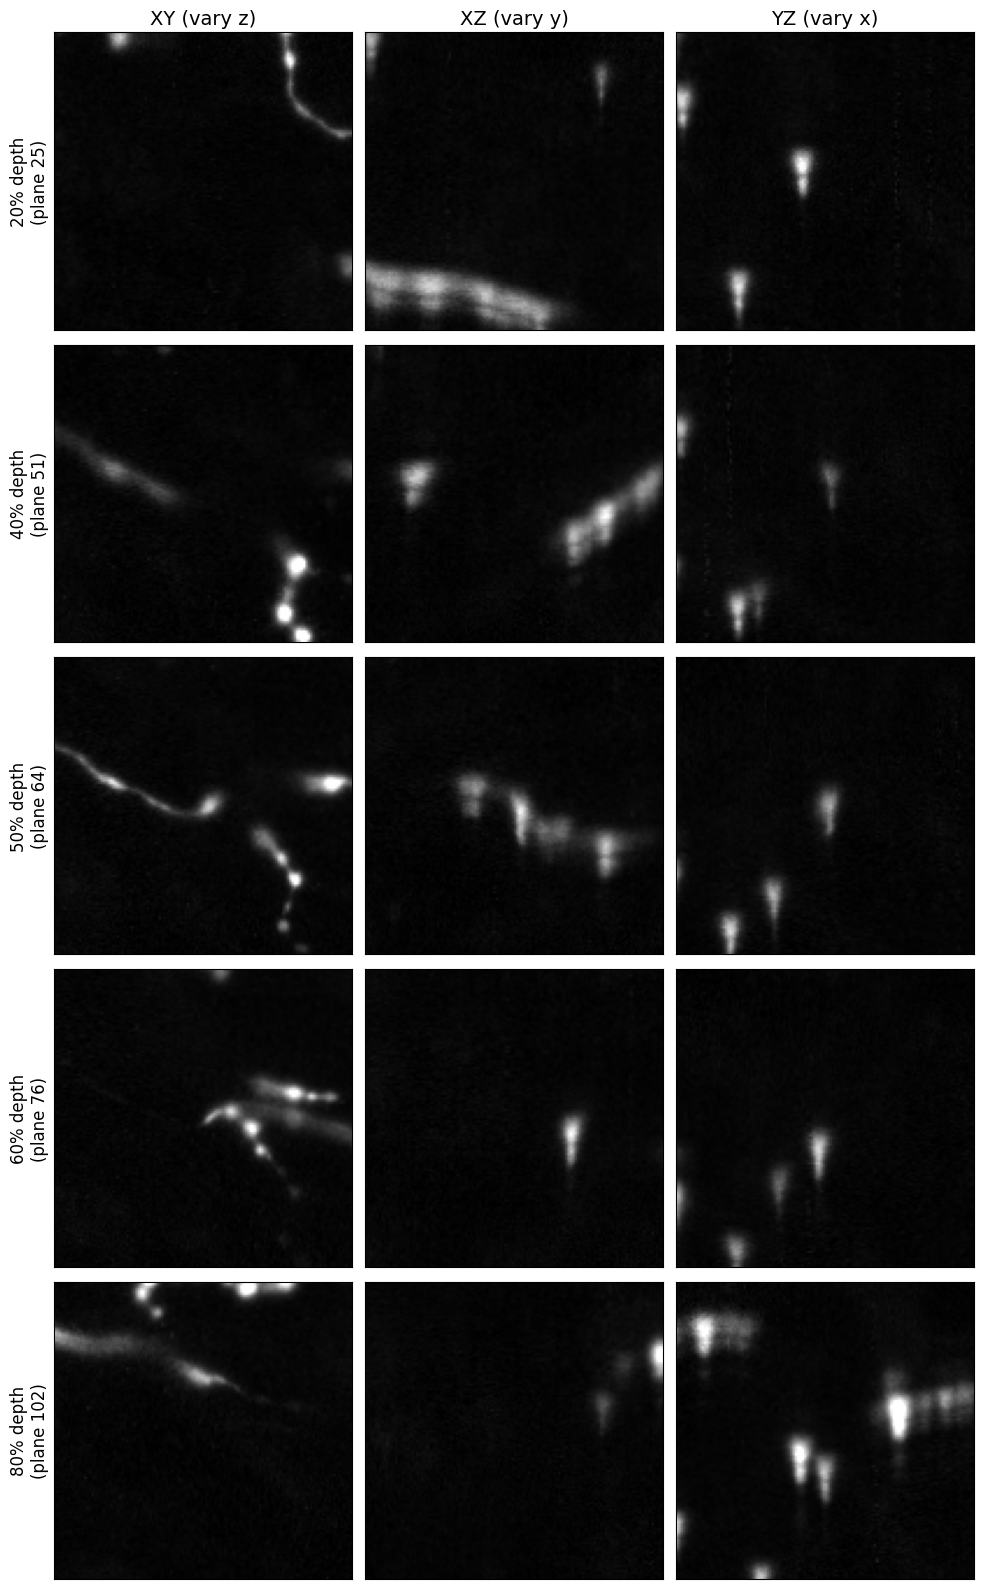

UNet segmentation (7 segment ids in patch) (MIP):


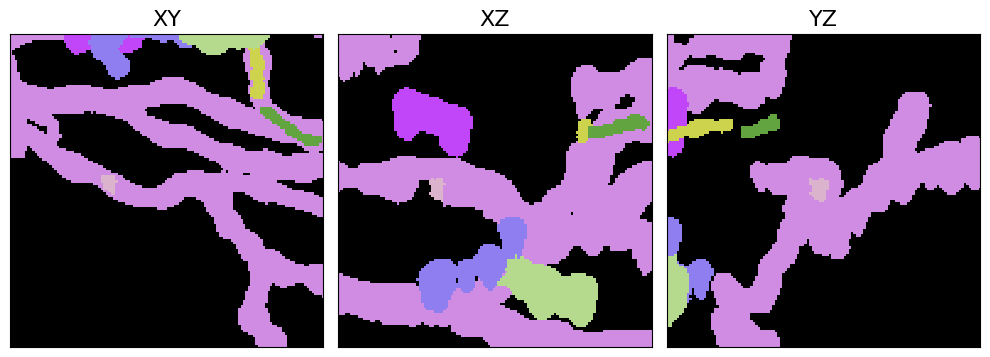

GT nodes/edges in patch: 125/116   fragment nodes/edges: 0/0


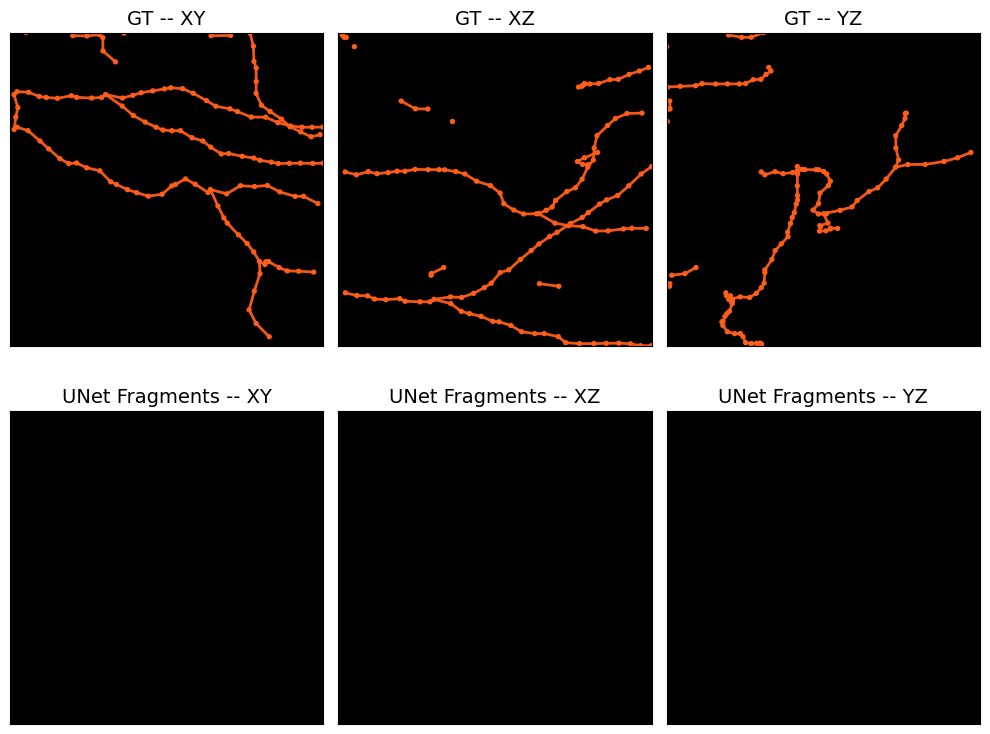

In [5]:
if merge_sites:
    # Geometric-walk-only segments = union (cached merge_labels) MINUS the
    # node-count rule. These are the merges the node-count rule cannot see
    # (fused partner unlabelled -> the segment touches only one GT neuron).
    nc_set = {int(x) for x in cl.merge_labels(gt, node_label)}
    union_set = {int(x) for x in (getattr(gt, "merge_labels", None)
                                  if getattr(gt, "merge_labels", None) is not None else [])}
    geo_only_segs = union_set - nc_set

    # Keep only the merge sites whose segment is geometric-only.
    geo_sites = [s for s in merge_sites if int(s["segment_id"]) in geo_only_segs]
    assert geo_sites, ("no geometric-only merge sites in this cache "
                       "(all merges are also node-count merges) -- try another brain.")
    print(f"{len(geo_sites)}/{len(merge_sites)} merge sites are geometric-walk-only "
          f"(segment missed by the node-count rule).")

    site = geo_sites[int(rng.integers(len(geo_sites)))]
    merge_xyz = tuple(map(float, site["xyz"]))
    print("geometric-walk merge site:", site, "\n")
else:
    merged_idx = np.flatnonzero(edge_error == cl.EDGE_MERGED)
    assert merged_idx.size, "no merge sites and no merged edges in this cache"
    pick = int(rng.choice(merged_idx))
    i, j = edges[pick]
    merge_xyz = tuple(map(float, (gt.node_xyz[i] + gt.node_xyz[j]) / 2.0))
    print(f"merged edge #{pick}: nodes ({i}, {j}), seg id {gt.node_label[i]}\n")

merge_center = show_receptive_field(
    merge_xyz, f"GEOMETRIC-WALK MERGE @ {tuple(round(v, 1) for v in merge_xyz)} um"
)

## 4b. Merge labels: node-count rule vs. geometric walk (a UNION, not a sum)

The cache's `gt_merge_labels` is the **set UNION** of the two detectors
(`datasets.py`: `merge_set = merge_set | geo_labels`), not the two counts added:
a segment id flagged by both rules is counted once. So
`len(node_count) + len(geo) >= len(union)`, with equality only when the two
sets are disjoint. The cell below breaks the union into three parts:
node-count only, recovered by the geometric walk only, and flagged by both.

In [6]:
# Node-count rule set (recomputed from the baked-in labels; no segmentation read).
node_count_set = {int(x) for x in cl.merge_labels(gt, node_label)}

# The union stored in the cache = node-count rule | geometric walk.
union_set = {int(x) for x in (getattr(gt, "merge_labels", None)
                              if getattr(gt, "merge_labels", None) is not None else [])}
if not union_set:
    union_set = node_count_set  # cache predates the geometric walk

# Three DISJOINT pieces of the union (no segment counted twice -> these DO add up).
nc_only  = node_count_set - union_set   # node-count labels missing from the union (expect 0)
both     = union_set & node_count_set   # flagged by BOTH rules
geo_only = union_set - node_count_set   # recovered ONLY by the geometric walk

# Each rule's TOTAL output. These two OVERLAP on `both`, so they must NOT be added.
node_count_total = len(node_count_set)           # = both + nc_only
geo_total        = len(both) + len(geo_only)     # geometric walk total (includes the overlap)

print("Disjoint partition of the union (these ADD UP):")
print(f"  node-count only : {len(nc_only):>3}   (expect 0)")
print(f"  both rules      : {len(both):>3}")
print(f"  geo-only        : {len(geo_only):>3}")
print(f"  => {len(nc_only)} + {len(both)} + {len(geo_only)} = {len(union_set)} = union  ✓")

print("\nEach rule's TOTAL output (these OVERLAP -> do NOT add them):")
print(f"  node-count total: {node_count_total:>3}   (= both {len(both)} + node-count-only {len(nc_only)})")
print(f"  geometric total : {geo_total:>3}   (= both {len(both)} + geo-only {len(geo_only)})")
print(f"  adding them double-counts the {len(both)} shared: "
      f"{node_count_total} + {geo_total} = {node_count_total + geo_total} != {len(union_set)}")

print(f"\nTakeaway: the brain has {len(union_set)} merge segments; the node-count rule "
      f"alone finds {node_count_total}, the geometric walk adds {len(geo_only)} it misses.")

Disjoint partition of the union (these ADD UP):
  node-count only :   0   (expect 0)
  both rules      :   6
  geo-only        :   0
  => 0 + 6 + 0 = 6 = union  ✓

Each rule's TOTAL output (these OVERLAP -> do NOT add them):
  node-count total:   6   (= both 6 + node-count-only 0)
  geometric total :   6   (= both 6 + geo-only 0)
  adding them double-counts the 6 shared: 6 + 6 = 12 != 6

Takeaway: the brain has 6 merge segments; the node-count rule alone finds 6, the geometric walk adds 0 it misses.


### 4c. Confirm it really is a merge — and understand *which* kind

There are **two** canonical merge definitions in `canonical_labeling.py`, and a site
can come from either (the cache stores the union):

1. **Node-count rule** (`merge_labels`): one predicted segment lands GT nodes on
   **≥ 2 different GT neurons** (each with ≥ `MERGE_MIN_NODES` nodes). Both fused
   neurons are visible *in the GT labelling itself*.
2. **Geometric walk** (`geometric_merge_sites`): the fragment for that segment has a
   leaf sitting **> `MERGE_DIST_AWAY_UM` (50 µm) away from all GT**, and walking inward
   it **re-approaches a GT neuron within `MERGE_APPROACH_UM` (6 µm)**. The merge is a
   stray piece of cable that loops far out and comes back — it fuses something onto
   the neuron *physically*, but that something **need not be a labelled GT neuron**, so
   it can touch only **one** GT neuron's nodes.

So the right verification depends on the source. We run the node-count grouping
first; if it shows only one neuron, this site is the **geometric** kind, and we then
reproduce the geometric walk for this one segment to show the far-out leaf that
triggered it. A "1 GT neuron" result is therefore **expected and not a contradiction**
— it is exactly the case the geometric walk was added to catch (the node-count rule
alone misses it).

In [7]:
# --- (1) Node-count view: which GT neurons carry this predicted segment id? ----
# gt.node_label[k] is the predicted segment id at GT node nodes[k].
merge_seg_id = int(site["segment_id"]) if merge_sites else int(gt.node_label[i])
node_label_arr = np.asarray(gt.node_label)
nodes = list(gt.nodes)

hits = np.flatnonzero(node_label_arr == merge_seg_id)
neuron_counts = Counter(gt.node_segment_id(nodes[k]) for k in hits)

print(f"predicted segment {merge_seg_id} touches {len(hits)} GT nodes "
      f"across {len(neuron_counts)} GT neuron(s):")
for neuron, n in neuron_counts.most_common():
    flag = "  <- counts (>= MERGE_MIN_NODES)" if n >= cl.MERGE_MIN_NODES else ""
    print(f"  {neuron:<22} {n:>6} nodes{flag}")

substantial = [nrn for nrn, n in neuron_counts.items() if n >= cl.MERGE_MIN_NODES]
print(f"\nMERGE_MIN_NODES={cl.MERGE_MIN_NODES}  "
      f"MERGE_DIST_AWAY_UM={cl.MERGE_DIST_AWAY_UM}  "
      f"MERGE_APPROACH_UM={cl.MERGE_APPROACH_UM}")

if len(substantial) >= 2:
    print(f"\n=> NODE-COUNT MERGE: this segment spans {len(substantial)} GT neurons "
          f"{substantial}.")
else:
    # --- (2) Geometric view: reproduce the walk for THIS segment ---------------
    # A single-neuron node-count means this is a geometric-walk merge. Find the
    # fragment(s) for this segment, the leaf >MERGE_DIST_AWAY_UM from all GT, and
    # walk inward to the <MERGE_APPROACH_UM re-approach that recorded the site.
    print("\n=> only 1 GT neuron by node-count -> this is a GEOMETRIC-WALK merge.")
    print("   Reproducing the walk for this segment:")
    if gt.kdtree is None:
        gt.set_kdtree()
    fx = frags.node_xyz
    # Fragment components whose segment id == merge_seg_id (label appears on GT).
    seg_comps = [
        comp_nodes for sid, comp_nodes in
        cl._fragment_components(frags, only_labels={merge_seg_id})
        if sid == merge_seg_id
    ]
    label_nodes = {merge_seg_id: [nodes[k] for k in hits]}
    gt_comps = cl._gt_label_components(gt, merge_seg_id, label_nodes)
    found = False
    for comp_nodes in seg_comps:
        node_set = set(comp_nodes)
        leaves = [n for n in comp_nodes if frags.degree[n] == 1]
        # The leaf that is farthest from all GT (the stray, far-out tip).
        leaf_dists = [(float(gt.kdtree.query(fx[n])[0]), n) for n in leaves]
        far = [(d, n) for d, n in leaf_dists if d > cl.MERGE_DIST_AWAY_UM]
        if not far:
            continue
        d_leaf, leaf = max(far)
        s = cl._walk_to_merge_site(
            frags, gt, node_label_arr, gt.kdtree, leaf, node_set, set(),
            merge_seg_id, gt_comps, fx,
        )
        n_far = len(far)
        print(f"   fragment component: {len(comp_nodes)} nodes, {len(leaves)} leaves, "
              f"{n_far} leaf(s) > {cl.MERGE_DIST_AWAY_UM}um from GT")
        print(f"   farthest stray leaf: {d_leaf:.1f}um from any GT node (xyz={tuple(round(float(v),1) for v in fx[leaf])})")
        if s is not None:
            print(f"   walked inward -> re-approached GT neuron {s['gt_neuron']} "
                  f"(< {cl.MERGE_APPROACH_UM}um) at xyz={tuple(round(v,1) for v in s['xyz'])}")
            print("   => MERGE CONFIRMED: a stray arm loops >50um out and returns to "
                  "fuse onto the neuron — invisible to the node-count rule.")
            found = True
            break
    if not found:
        print("   (no far-out leaf reproduced here; the recorded site survived "
              "dedup across the brain — see cl.geometric_merge_sites)")

predicted segment 669567784 touches 619061 GT nodes across 24 GT neuron(s):
  N006-709221-JG         123939 nodes  <- counts (>= MERGE_MIN_NODES)
  N016-709221-KP          80319 nodes  <- counts (>= MERGE_MIN_NODES)
  N015-709221-SP          43550 nodes  <- counts (>= MERGE_MIN_NODES)
  N018-709221-PP          36307 nodes  <- counts (>= MERGE_MIN_NODES)
  N017-709221-SP          35394 nodes  <- counts (>= MERGE_MIN_NODES)
  N020-709221-SP          25628 nodes  <- counts (>= MERGE_MIN_NODES)
  N005-709221-MB          24918 nodes  <- counts (>= MERGE_MIN_NODES)
  N060-709221-JG          22745 nodes  <- counts (>= MERGE_MIN_NODES)
  N056-709221-BL          22022 nodes  <- counts (>= MERGE_MIN_NODES)
  N063-709221-MB          19581 nodes  <- counts (>= MERGE_MIN_NODES)
  N057-709221-SA          19103 nodes  <- counts (>= MERGE_MIN_NODES)
  N021-709221-FB          17502 nodes  <- counts (>= MERGE_MIN_NODES)
  N055-709221-PP          17136 nodes  <- counts (>= MERGE_MIN_NODES)
  N019-709221-

### 4d. A NODE-COUNT merge (the other kind): one segment on ≥ 2 GT neurons

The random merge above came from the geometric walk and touched only one GT neuron.
Here we find a **node-count** merge instead: scan the brain for a predicted segment
that lands ≥ `MERGE_MIN_NODES` GT nodes on **two different GT neurons**, then frame the
**contact point** — the closest pair of GT nodes from the two neurons that both carry
that segment. In the panels you should see the *segmentation* paint **one color across
both neurons**, while the *GT skeleton* shows **two independent neurons** meeting there
— the visual signature of a node-count merge.

6 node-count merge segment(s) in brain 709221.

segment 3688657785 spans 2 GT neurons; two largest:
  N004-709221-SP: 194 nodes
  N002-709221-SP: 97 nodes
  contact gap: 0.6 um

=== NODE-COUNT MERGE: seg 3688657785 fuses N004-709221-SP + N002-709221-SP @ (22180.9, 16053.8, 8479.4) um ===
  location (um): (22180.9, 16053.8, 8479.4)
  center voxel (z,y,x): (8479, 21462, 29653)   patch: (128, 128, 128)
Raw image (MIP):


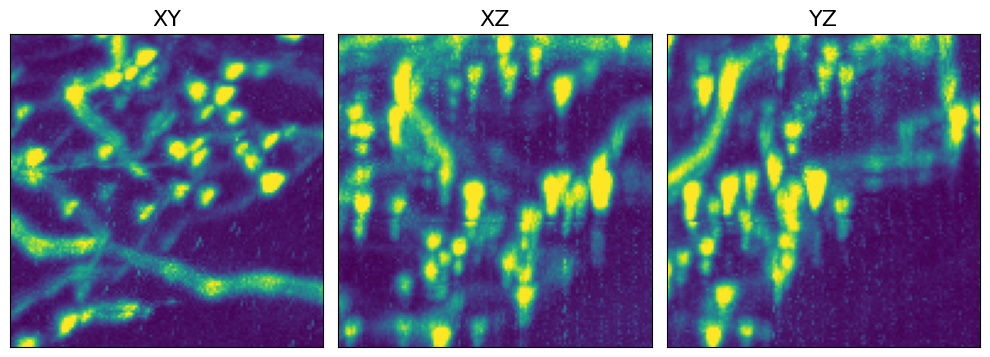

Raw image (slices at [20, 40, 50, 60, 80]% depth):


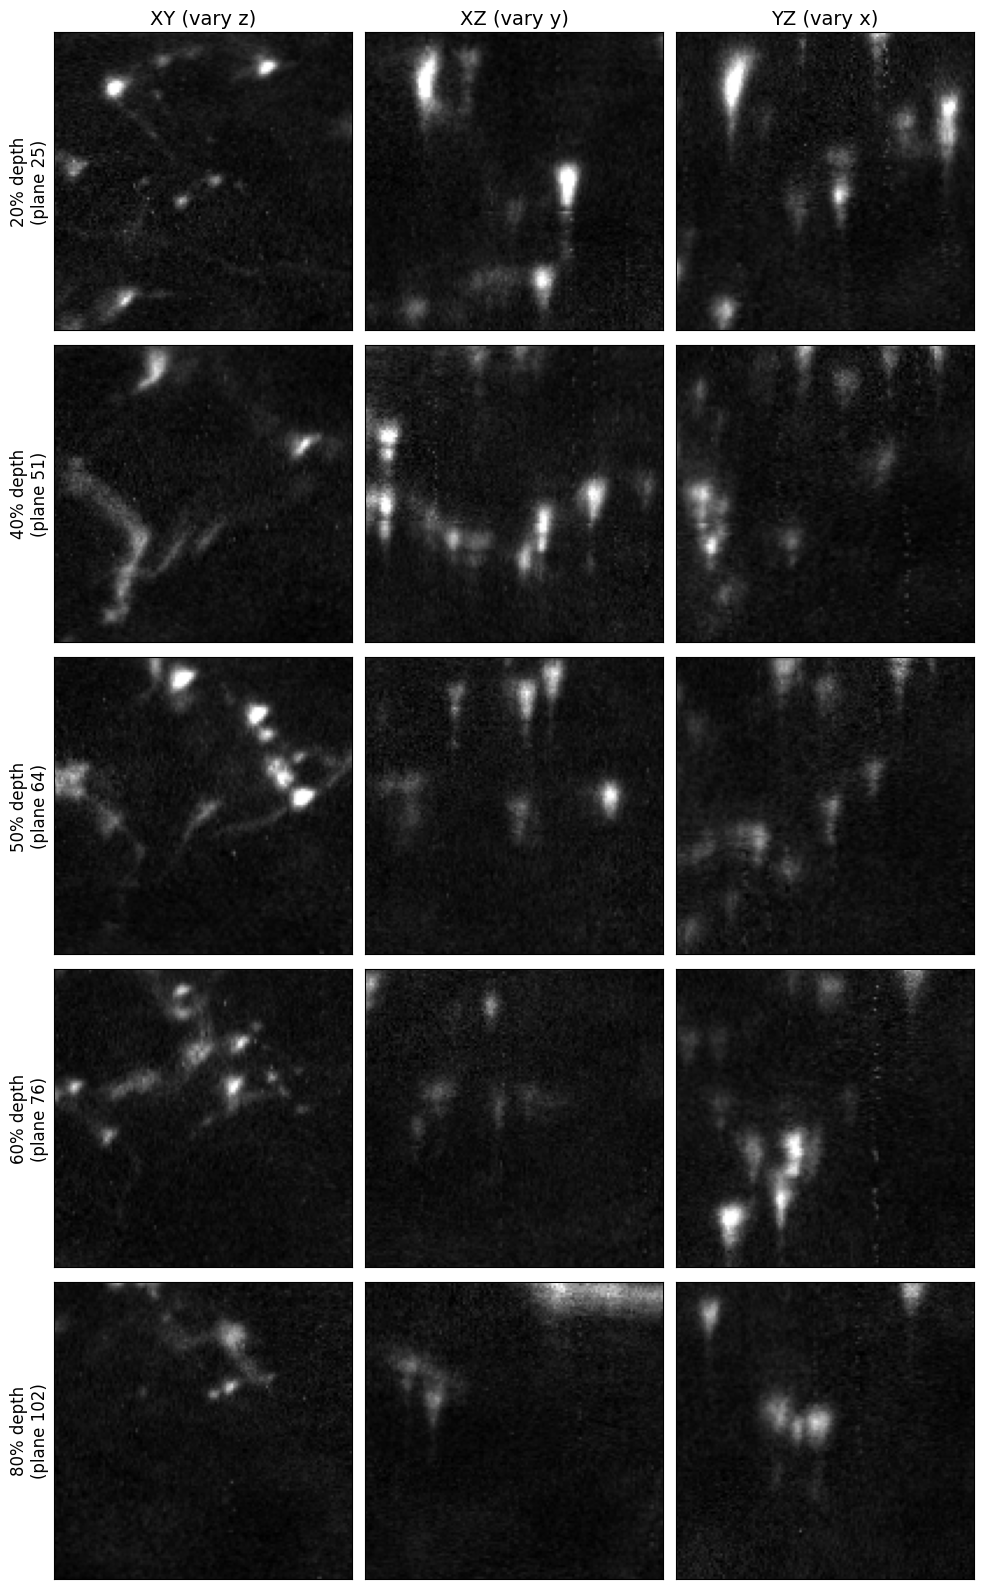

UNet segmentation (48 segment ids in patch) (MIP):


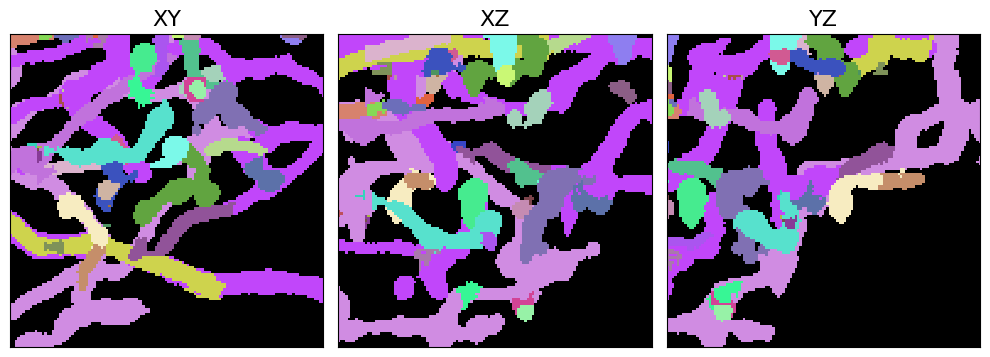

GT nodes/edges in patch: 82/80   fragment nodes/edges: 0/0


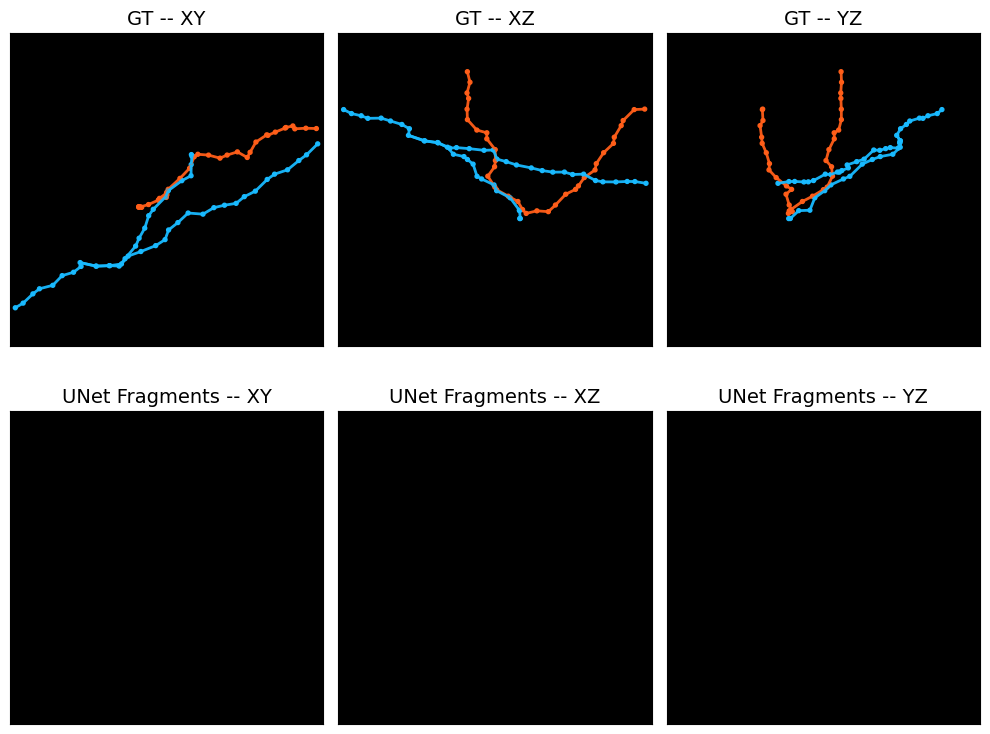

In [8]:
from scipy.spatial import KDTree

# Node-count merge segments, via the SAME library rule that baked the cache
# (cl.merge_labels: a segment with > MERGE_MIN_NODES GT nodes on >= 2 neurons).
node_label_arr = np.asarray(gt.node_label)
nodes = list(gt.nodes)
seg_counts = cl.segment_neuron_node_counts(gt, node_label_arr)  # seg -> {neuron: n}
nodecount_segs = sorted(cl.merge_labels(gt, node_label_arr))     # set of seg ids

print(f"{len(nodecount_segs)} node-count merge segment(s) in brain {BRAIN_ID}.")

if not nodecount_segs:
    # Not an error: this brain's merges may ALL be geometric-walk ones (the kind
    # in section 4). To see a node-count merge, set BRAIN_ID to another *_add.pkl
    # (e.g. 789202 / 794491 / 794495 / 802449), re-run from cell 1, then this cell.
    print("=> none here. All merges in this brain are the geometric-walk kind "
          "(section 4). Switch BRAIN_ID to another brain and re-run to see one.")
else:
    # Pick one (deterministic via the notebook RNG); use its two biggest neurons.
    seg_id = nodecount_segs[int(rng.integers(len(nodecount_segs)))]
    big = sorted(((nrn, n) for nrn, n in seg_counts[seg_id].items()
                  if n > cl.MERGE_MIN_NODES), key=lambda t: -t[1])
    (nrn_a, na), (nrn_b, nb) = big[0], big[1]
    print(f"\nsegment {seg_id} spans {len(big)} GT neurons; two largest:")
    print(f"  {nrn_a}: {na} nodes\n  {nrn_b}: {nb} nodes")

    # Contact point = closest pair of this-segment GT nodes, one from each neuron.
    on_seg = [nodes[k] for k in np.flatnonzero(node_label_arr == seg_id)]
    idx_a = [n for n in on_seg if gt.node_segment_id(n) == nrn_a]
    idx_b = [n for n in on_seg if gt.node_segment_id(n) == nrn_b]
    xyz_a, xyz_b = gt.node_xyz[idx_a], gt.node_xyz[idx_b]
    d, j = KDTree(xyz_a).query(xyz_b, k=1)
    ib = int(np.argmin(d))
    contact_xyz = tuple(map(float, (xyz_a[int(j[ib])] + xyz_b[ib]) / 2.0))
    print(f"  contact gap: {float(d[ib]):.1f} um\n")

    nodecount_center = show_receptive_field(
        contact_xyz,
        f"NODE-COUNT MERGE: seg {seg_id} fuses {nrn_a} + {nrn_b} @ "
        f"{tuple(round(v, 1) for v in contact_xyz)} um",
    )

## 5. (Optional) the two receptive fields as ready-to-use records

`{kind, xyz_um, center_voxel}` — re-read the image / segmentation / skeletons at
any `PATCH` size from `xyz_um` via `receptive_field(...)` / `show_receptive_field(...)`.

In [9]:
samples = [
    {"kind": "split", "xyz_um": split_xyz, "center_voxel": split_center},
    {"kind": "merge", "xyz_um": merge_xyz, "center_voxel": merge_center},
]
for s in samples:
    print(f"{s['kind']:<6} xyz_um={tuple(round(v, 1) for v in s['xyz_um'])} "
          f"center_voxel={s['center_voxel']}")

split  xyz_um=(23798.2, 18764.0, 8867.9) center_voxel=(8867, 25085, 31815)
merge  xyz_um=(24343.7, 21161.2, 8963.0) center_voxel=(8963, 28290, 32545)
